In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bandits = [0.2, 0.5, 0.75, 0.9]

print("Bandits Created")

Bandits Created


In [3]:
n_bandits = len(bandits)

Q = np.zeros(n_bandits)

N = np.zeros(n_bandits)

epsilon = 0.1

rewards = []

print("Q Values:", Q)

Q Values: [0. 0. 0. 0.]


In [4]:
for round in range(1000):

    if np.random.rand() < epsilon:

        action = np.random.randint(n_bandits)

    else:

        action = np.argmax(Q)

    reward = np.random.binomial(1, bandits[action])

    N[action] += 1

    Q[action] += (reward - Q[action]) / N[action]

    rewards.append(reward)

In [5]:
print("Estimated Values:")

for i in range(n_bandits):
    print(f"Bandit {i}: {Q[i]:.3f}")

Estimated Values:
Bandit 0: 0.241
Bandit 1: 0.385
Bandit 2: 0.690
Bandit 3: 0.898


In [6]:
best_bandit = np.argmax(Q)

print("Best Bandit Learned =", best_bandit)

Best Bandit Learned = 3


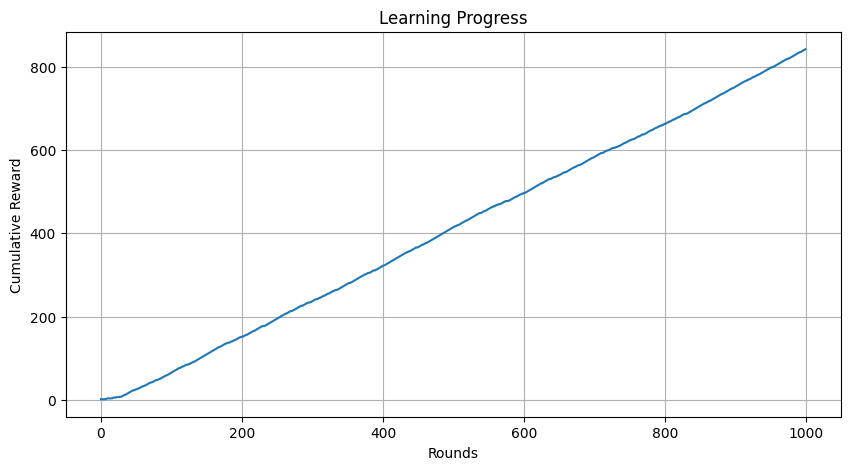

In [7]:
cumulative_rewards = np.cumsum(rewards)

plt.figure(figsize=(10,5))
plt.plot(cumulative_rewards)
plt.xlabel("Rounds")
plt.ylabel("Cumulative Reward")
plt.title("Learning Progress")
plt.grid()
plt.show()

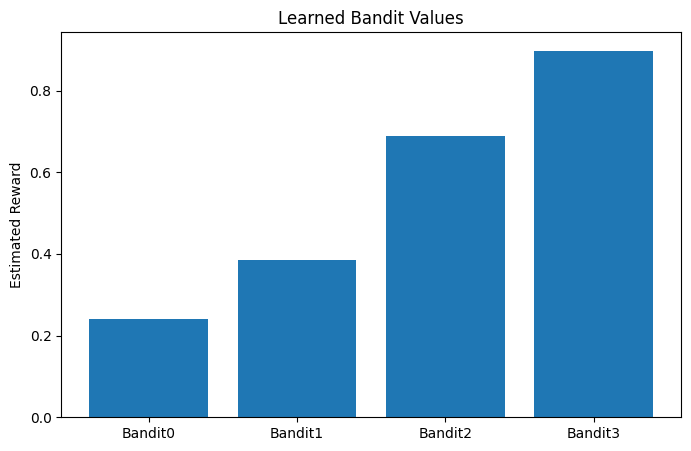

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    ['Bandit0','Bandit1','Bandit2','Bandit3'],
    Q
)

plt.title("Learned Bandit Values")
plt.ylabel("Estimated Reward")
plt.show()

In [9]:
for i in range(n_bandits):
    print(f"Bandit {i} selected {int(N[i])} times")

Bandit 0 selected 54 times
Bandit 1 selected 26 times
Bandit 2 selected 29 times
Bandit 3 selected 891 times


In [10]:
print("Actual Probabilities :", bandits)
print("Learned Values       :", Q)
print("Best Arm Found       :", np.argmax(Q))

Actual Probabilities : [0.2, 0.5, 0.75, 0.9]
Learned Values       : [0.24074074 0.38461538 0.68965517 0.89786756]
Best Arm Found       : 3
